# Customer Churn Analysis — EDA and Predictive Model

Analysis of a telecom customer base (7,043 customers) to identify churn drivers and build a
predictive model. Uses the same underlying data as the SQL analysis in `../sql/analysis_queries.sql`
— this notebook focuses on visual exploration and a classification model; the SQL file focuses on
the business-facing summary tables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix
)

plt.rcParams['figure.figsize'] = (7, 4)
pd.set_option('display.max_columns', None)

## 1. Load and clean

In [2]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# TotalCharges is stored as text and has 11 blank values (all customers with tenure == 0,
# i.e. brand-new customers who haven't been billed yet) -- drop these for modelling.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('Blank TotalCharges:', df['TotalCharges'].isna().sum())
df = df.dropna(subset=['TotalCharges']).copy()
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print('Rows after cleaning:', len(df))
print('Churn rate:', round(df['Churn'].mean(), 4))

Blank TotalCharges: 11
Rows after cleaning: 7032
Churn rate: 0.2658


## 2. Exploratory analysis\n\nConfirms the same patterns found in the SQL analysis.

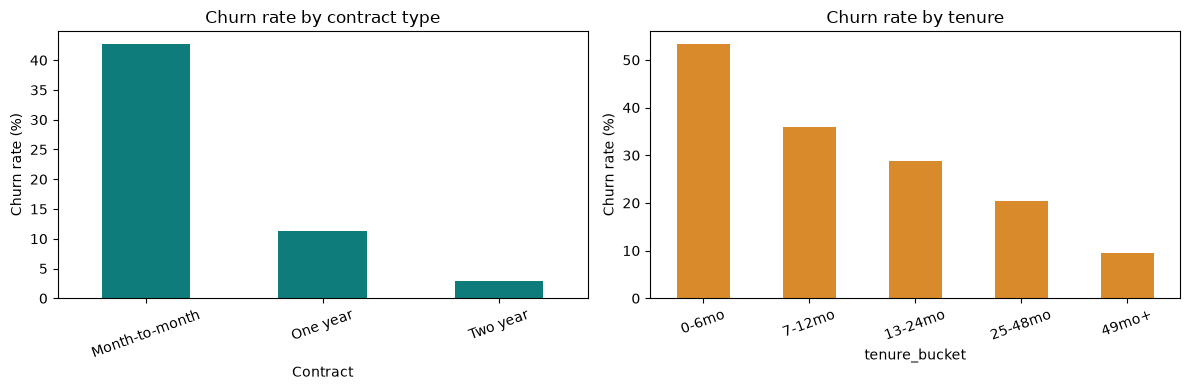

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False) * 100
contract_churn.plot(kind='bar', ax=axes[0], color='#0E7C7B')
axes[0].set_title('Churn rate by contract type')
axes[0].set_ylabel('Churn rate (%)')
axes[0].tick_params(axis='x', rotation=20)

df['tenure_bucket'] = pd.cut(df['tenure'], bins=[-1, 6, 12, 24, 48, 100],
                              labels=['0-6mo', '7-12mo', '13-24mo', '25-48mo', '49mo+'])
tenure_churn = df.groupby('tenure_bucket', observed=True)['Churn'].mean() * 100
tenure_churn.plot(kind='bar', ax=axes[1], color='#D98A2B')
axes[1].set_title('Churn rate by tenure')
axes[1].set_ylabel('Churn rate (%)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

Contract type and tenure are the two strongest visible drivers — month-to-month customers and
customers in their first 6 months churn at roughly 5-15x the rate of long-tenure, long-contract
customers.

## 3. Feature preparation

In [5]:
y = df['Churn']
X = df.drop(columns=['customerID', 'Churn', 'tenure_bucket'])

cat_cols = X.select_dtypes(include='object').columns.tolist()
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Baseline (always predict "no churn") accuracy:', round(1 - y_test.mean(), 4))

Train: (5625, 30)  Test: (1407, 30)
Baseline (always predict "no churn") accuracy: 0.7342


C:\Users\aakra\AppData\Local\Temp\ipykernel_22324\4081602347.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


The baseline matters here: because only ~27% of customers churn, a model that always predicts
"no churn" would already be ~73% "accurate" while being useless for the business. Recall (catching
actual churners) and ROC-AUC matter more than raw accuracy for this problem.

## 4. Logistic Regression

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('Accuracy: ', round(accuracy_score(y_test, pred_lr), 4))
print('Precision:', round(precision_score(y_test, pred_lr), 4))
print('Recall:   ', round(recall_score(y_test, pred_lr), 4))
print('F1:       ', round(f1_score(y_test, pred_lr), 4))
print('ROC-AUC:  ', round(roc_auc_score(y_test, proba_lr), 4))

Accuracy:  0.8038
Precision: 0.6476
Recall:    0.5749
F1:        0.6091
ROC-AUC:   0.8357


## 5. Random Forest (class-balanced)\n\nTrying a second model to see if recall improves — retention campaigns are usually more concerned with catching likely churners (recall) than being precise about every flag.

In [7]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

print('Accuracy: ', round(accuracy_score(y_test, pred_rf), 4))
print('Precision:', round(precision_score(y_test, pred_rf), 4))
print('Recall:   ', round(recall_score(y_test, pred_rf), 4))
print('F1:       ', round(f1_score(y_test, pred_rf), 4))
print('ROC-AUC:  ', round(roc_auc_score(y_test, proba_rf), 4))

Accuracy:  0.7392
Precision: 0.5059
Recall:    0.8021
F1:        0.6205
ROC-AUC:   0.8382


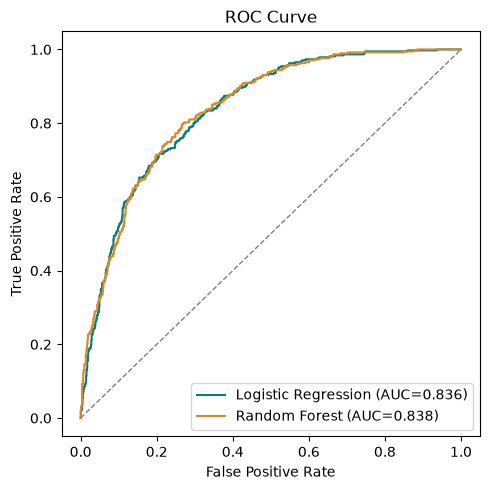

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
for name, proba, color in [('Logistic Regression', proba_lr, '#0E7C7B'), ('Random Forest', proba_rf, '#D98A2B')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})', color=color)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.tight_layout()
plt.show()

## 6. What actually drives churn, according to the model

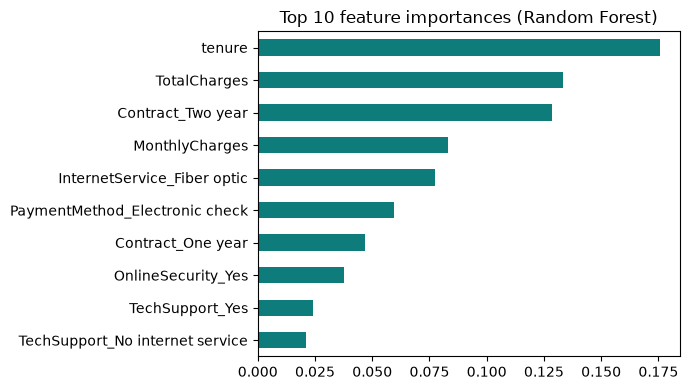

In [9]:
importances = pd.Series(rf.feature_importances_, index=X_encoded.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh', color='#0E7C7B', figsize=(7, 4))
plt.gca().invert_yaxis()
plt.title('Top 10 feature importances (Random Forest)')
plt.tight_layout()
plt.show()

## Conclusion

- Both models land around **0.83-0.84 ROC-AUC**, meaningfully better than the 0.73 baseline.
- Logistic Regression gives higher precision (0.65) — fewer false alarms, useful if retention offers are costly.
- The balanced Random Forest gives higher recall (0.80) — catches more actual churners, at the cost of more false positives. For a retention campaign, this trade-off is usually worth it: a missed churner is a lost customer, a false positive just gets an unnecessary discount offer.
- Feature importances confirm the SQL analysis: **tenure, contract length, and charges** are the dominant drivers — not customer satisfaction score or support interaction sentiment, which showed almost no correlation with churn in the SQL analysis (`analysis_queries.sql`, query 8-9). That's a genuinely useful, slightly counter-intuitive finding: this business's churn problem looks structural (contract terms, price, tenure) rather than a service-quality problem.
